# Accidents de la route 2024 — profiling et qualité des données

On a 4 fichiers reliés par `Num_Acc` : `caract` (l'accident), `lieux` (la route),
`vehicules` (les véhicules) et `usagers` (les personnes).

But : regarder chaque table pour comprendre les données et repérer les problèmes de qualité
(valeurs manquantes, valeurs bizarres, doublons).

## 1. Charger les fichiers

Le séparateur est `;`, la virgule est le séparateur décimal, et `-1` / vide / `N/A` veut dire
« non renseigné ».

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import glob

def charger(nom):
    fichier = glob.glob(nom + "*.csv")[0]      # trouve le fichier quelle que soit l'annee
    return pd.read_csv(fichier, sep=";", decimal=",",
                       na_values=["-1", " -1", "N/A"], low_memory=False)

caract = charger("caract")
lieux = charger("lieux")
vehicules = charger("vehicules")
usagers = charger("usagers")

print("caract   :", caract.shape)
print("lieux    :", lieux.shape)
print("vehicules:", vehicules.shape)
print("usagers  :", usagers.shape)

annee = int(caract["an"].mode()[0])
print("Annee des donnees :", annee)

caract   : (54402, 15)
lieux    : (70248, 18)
vehicules: (92678, 11)
usagers  : (125187, 16)
Annee des donnees : 2024


## 2. Aperçu des données

In [2]:
caract.head(3)

,Num_Acc,jour,mois,an,hrmn,lum,dep,com,agg,int,atm,col,adr,lat,long
0,202400000001,25,3,2024,07:40,2,70,70285,1,1,5,1.0,D438,47.562770,6.758320
1,202400000002,20,3,2024,15:05,1,21,21054,2,3,7,6.0,HOTEL DIEU (RUE DE L'),47.021090,4.837550
2,202400000003,22,3,2024,19:30,2,15,15012,1,1,1,6.0,Allée des Tilleuls,44.902384,2.496418


In [3]:
usagers.head(3)

,Num_Acc,id_usager,id_vehicule,num_veh,place,catu,grav,sexe,an_nais,trajet,secu1,secu2,secu3,locp,actp,etatp
0,202400000001,203 988 581,155 781 758,A01,1.0,1,3,1.0,2003.0,2.0,1.0,NaN,NaN,NaN,NaN,NaN
1,202400000001,203 988 582,155 781 759,B01,1.0,1,1,1.0,1997.0,4.0,1.0,NaN,NaN,NaN,NaN,NaN
2,202400000002,203 988 579,155 781 757,A01,10.0,3,3,2.0,1927.0,5.0,0.0,NaN,NaN,3.0,3,1.0


## 3. Types des colonnes

In [4]:
tables = {"caract": caract, "lieux": lieux, "vehicules": vehicules, "usagers": usagers}

for nom, table in tables.items():
    print("---", nom, "---")
    print(table.dtypes)
    print()

--- caract ---
Num_Acc      int64
jour         int64
mois         int64
an           int64
hrmn        object
lum          int64
dep         object
com         object
agg          int64
int          int64
atm          int64
col        float64
adr         object
lat        float64
long       float64
dtype: object

--- lieux ---
Num_Acc      int64
catr         int64
voie        object
v1         float64
v2          object
circ       float64
nbv         object
vosp       float64
prof       float64
pr          object
pr1         object
plan       float64
lartpc     float64
larrout    float64
surf       float64
infra      float64
situ       float64
vma        float64
dtype: object

--- vehicules ---
Num_Acc          int64
id_vehicule     object
num_veh         object
senc           float64
catv           float64
obs            float64
obsm           float64
choc           float64
manv           float64
motor          float64
occutc         float64
dtype: object

--- usagers ---
Num_Acc     

On a des identifiants (`Num_Acc`, `id_usager`…), des codes (`grav`, `sexe`, `lum`… ce sont des
catégories, pas des nombres) et quelques vraies mesures (`lat`, `long`, `an_nais`, `vma`).
La colonne importante est `grav` : la gravité (1 indemne, 2 tué, 3 blessé hospitalisé, 4 blessé léger).

## 4. Profil de chaque colonne

Pour chaque colonne : son type, combien de valeurs manquent, et combien de valeurs différentes elle a.

In [5]:
def profil(table):
    resume = pd.DataFrame()
    resume["type"] = table.dtypes
    resume["nb_manquants"] = table.isnull().sum()
    resume["pct_manquants"] = (table.isnull().mean() * 100).round(1)
    resume["nb_valeurs_differentes"] = table.nunique()
    return resume

profil(caract)

,type,nb_manquants,pct_manquants,nb_valeurs_differentes
Num_Acc,int64,0,0.0,54402
jour,int64,0,0.0,31
mois,int64,0,0.0,12
an,int64,0,0.0,1
hrmn,object,0,0.0,1414
lum,int64,0,0.0,5
dep,object,0,0.0,107
com,object,0,0.0,11285
agg,int64,0,0.0,2
int,int64,0,0.0,9


In [6]:
profil(lieux)

,type,nb_manquants,pct_manquants,nb_valeurs_differentes
Num_Acc,int64,0,0.0,54402
catr,int64,0,0.0,8
voie,object,13331,19.0,19750
v1,float64,16272,23.2,3
v2,object,64332,91.6,27
circ,float64,4354,6.2,4
nbv,object,4178,5.9,14
vosp,float64,3832,5.5,4
prof,float64,50,0.1,4
pr,object,27364,39.0,460


In [7]:
profil(vehicules)

,type,nb_manquants,pct_manquants,nb_valeurs_differentes
Num_Acc,int64,0,0.0,54402
id_vehicule,object,0,0.0,92678
num_veh,object,0,0.0,45
senc,float64,68,0.1,4
catv,float64,1,0.0,31
obs,float64,27,0.0,18
obsm,float64,30,0.0,7
choc,float64,44,0.0,10
manv,float64,27,0.0,27
motor,float64,192,0.2,7


In [8]:
profil(usagers)

,type,nb_manquants,pct_manquants,nb_valeurs_differentes
Num_Acc,int64,0,0.0,54402
id_usager,object,0,0.0,125187
id_vehicule,object,0,0.0,92654
num_veh,object,0,0.0,45
place,float64,3,0.0,10
catu,int64,0,0.0,3
grav,int64,0,0.0,4
sexe,float64,2395,1.9,2
an_nais,float64,2579,2.1,105
trajet,float64,2626,2.1,7


## 5. Valeurs manquantes

Le pourcentage de valeurs manquantes, colonne par colonne.

In [9]:
for nom, table in tables.items():
    pct = (table.isnull().mean() * 100).round(1)
    pct = pct[pct > 0].sort_values(ascending=False)
    print("---", nom, "---")
    if len(pct) == 0:
        print("aucune valeur manquante")
    else:
        print(pct)
    print()

--- caract ---
adr    4.2
dtype: float64

--- lieux ---
lartpc     100.0
v2          91.6
larrout     69.2
pr1         39.1
pr          39.0
v1          23.2
voie        19.0
circ         6.2
nbv          5.9
vosp         5.5
vma          5.2
infra        1.2
prof         0.1
plan         0.1
surf         0.1
situ         0.1
dtype: float64

--- vehicules ---
occutc    99.0
motor      0.2
senc       0.1
dtype: float64

--- usagers ---
etatp      91.8
secu3      90.4
actp       49.3
locp       49.3
secu2      43.0
trajet      2.1
an_nais     2.1
sexe        1.9
secu1       1.7
dtype: float64



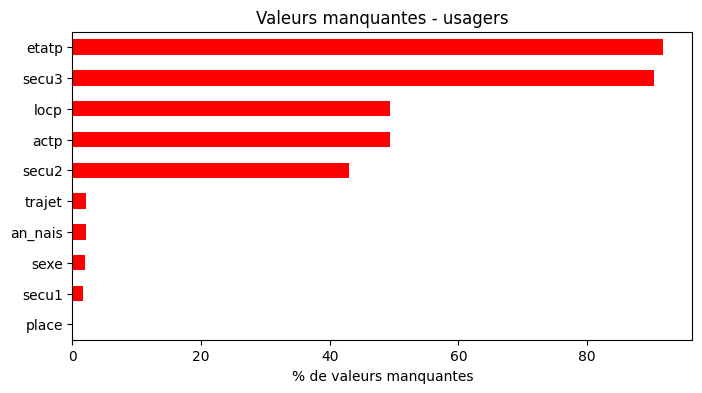

In [10]:
# graphique pour la table usagers
pct = (usagers.isnull().mean() * 100)
pct = pct[pct > 0].sort_values()
pct.plot(kind="barh", color="red", figsize=(8, 4))
plt.xlabel("% de valeurs manquantes")
plt.title("Valeurs manquantes - usagers")
plt.show()

**Conclusion par fichier :**

- **caract** : quasi complet, seule `adr` (l'adresse) manque un peu (~4 %).
- **lieux** : beaucoup de colonnes vides, mais ce sont des détails de route rarement remplis
  (`lartpc` 100 %, `v2` 92 %, `larrout` 69 %, `pr`/`pr1` ~39 %). Le seul manquant gênant est `vma` (~5 %).
- **vehicules** : quasi complet ; `occutc` (99 %) ne concerne que les bus, donc c'est normal.
- **usagers** : les gros manquants sont normaux (piétons ou 3ᵉ équipement : `etatp` 92 %, `secu3` 90 %,
  `locp`/`actp` ~49 %). Ceux qui gênent un peu : `an_nais`, `sexe`, `secu1` (~2 %). `grav` n'a aucun manquant.

## 6. Valeurs des colonnes codées

On regarde les valeurs prises par les colonnes codées, pour vérifier qu'il n'y a pas de valeur bizarre.

In [11]:
print("grav :")
print(usagers["grav"].value_counts().sort_index())
print("\nsexe :")
print(usagers["sexe"].value_counts().sort_index())
print("\ncatu (type d'usager) :")
print(usagers["catu"].value_counts().sort_index())
print("\nlum (luminosite) :")
print(caract["lum"].value_counts().sort_index())

grav :
grav
1    52920
2     3432
3    19126
4    49709
Name: count, dtype: int64

sexe :
sexe
1.0    83864
2.0    38928
Name: count, dtype: int64

catu (type d'usager) :
catu
1    92581
2    23205
3     9401
Name: count, dtype: int64

lum (luminosite) :
lum
1    35580
2     3599
3     6101
4      623
5     8499
Name: count, dtype: int64


Les valeurs correspondent bien à ce qui est attendu : `grav` va de 1 à 4, `sexe` vaut 1 ou 2,
`catu` de 1 à 3, `lum` de 1 à 5. Pas de catégorie inconnue.

## 7. Statistiques des colonnes numériques

In [12]:
caract[["lat", "long"]].describe()

,lat,long
count,54402.000000,54402.000000
mean,44.051229,1.240096
std,12.665655,19.460609
min,-22.433239,-178.094387
25%,44.519282,1.153567
50%,47.717121,2.392034
75%,48.861732,4.732405
max,51.078740,167.863219


In [13]:
age = annee - usagers["an_nais"]
age.describe()

count    122608.000000
mean         38.924589
std          19.327486
min           0.000000
25%          23.000000
50%          36.000000
75%          53.000000
max         110.000000
Name: an_nais, dtype: float64

Les âges vont de 0 à 110 ans (moyenne ~40), rien d'anormal. Les coordonnées couvrent la France
(métropole + outre-mer, ce qui explique les latitudes négatives).

## 8. Valeurs valides ?

On vérifie les colonnes les plus sensibles : coordonnées, âges et vitesse maximale.

### Coordonnées
Chaque point devrait être en France (métropole ou outre-mer). On liste les grandes zones françaises
et on repère les points qui ne sont dans aucune.

In [14]:
# (latitude min, latitude max, longitude min, longitude max) pour chaque zone francaise
zones_france = [
    (41.3, 51.1, -5.3, 9.6),      # metropole
    (14.3, 16.6, -61.9, -60.8),   # Antilles
    (2.0, 5.8, -54.7, -51.5),     # Guyane
    (-21.4, -12.4, 45.0, 55.9),   # Reunion + Mayotte
    (46.7, 47.2, -56.5, -56.1),   # Saint-Pierre-et-Miquelon
    (17.8, 18.2, -63.2, -62.7),   # Saint-Martin
    (-28, -7, -155, -134),        # Polynesie
    (-22.9, -19.5, 163.5, 168.2), # Nouvelle-Caledonie
    (-14.4, -13.1, -178.3, -176), # Wallis-et-Futuna
]

def en_france(lat, lon):
    for lat_min, lat_max, lon_min, lon_max in zones_france:
        if lat_min <= lat <= lat_max and lon_min <= lon <= lon_max:
            return True
    return False

caract["coord_ok"] = caract.apply(lambda ligne: en_france(ligne["lat"], ligne["long"]), axis=1)
mauvaises = caract[caract["coord_ok"] == False]
print("Coordonnees hors de France :", len(mauvaises))
mauvaises[["Num_Acc", "dep", "lat", "long"]]

Coordonnees hors de France : 9


,Num_Acc,dep,lat,long
2079,202400002080,976,45.16376,-12.78954
5347,202400005348,976,45.23097,12.75862
8234,202400008235,2B,9.44460,42.67720
11272,202400011273,2B,9.44085,42.65160
13465,202400013466,2B,9.44430,42.67720
18638,202400018639,976,45.23233,-12.78381
21732,202400021733,976,45.23507,12.78223
24443,202400024444,976,45.22950,-12.78421
49893,202400049894,976,45.22602,-12.76237


Ces 9 lignes ont la **latitude et la longitude inversées** : Mayotte (dep 976) devrait être vers
`lat -12, long 45` mais on trouve `lat 45, long -12`, et pareil pour la Haute-Corse (2B). Résultat : le
point tombe en pleine mer. À corriger (les permuter).

### Âges

In [15]:
age = annee - usagers["an_nais"]
print("Age minimum :", age.min())
print("Age maximum :", age.max())
print("Ages negatifs :", (age < 0).sum())
print("Ages au dessus de 110 ans :", (age > 110).sum())

Age minimum : 0.0
Age maximum : 110.0
Ages negatifs : 0
Ages au dessus de 110 ans : 0


### Vitesse maximale (vma)
En France la vitesse max autorisée ne dépasse pas 130 km/h.

In [16]:
vma_bizarre = lieux[lieux["vma"] > 130]
print("Vitesses max impossibles (> 130 km/h) :", len(vma_bizarre))
print("Valeurs trouvees :", sorted(vma_bizarre["vma"].dropna().unique()))

Vitesses max impossibles (> 130 km/h) : 29
Valeurs trouvees : [np.float64(140.0), np.float64(300.0), np.float64(301.0), np.float64(500.0), np.float64(700.0), np.float64(800.0), np.float64(900.0)]


Les âges sont corrects (0 à 110, aucun négatif). Par contre `vma` contient des valeurs
impossibles, jusqu'à **900 km/h** : ce sont des erreurs de saisie à nettoyer.

## 9. Doublons et clés

On regarde les lignes en double et si chaque table a un identifiant unique.

In [17]:
for nom, table in tables.items():
    print(nom, ":", table.duplicated().sum(), "doublon(s)")

caract : 0 doublon(s)
lieux : 2 doublon(s)
vehicules : 0 doublon(s)
usagers : 0 doublon(s)


In [18]:
# une cle primaire doit etre unique
print("caract    - Num_Acc unique ?    ", caract["Num_Acc"].is_unique)
print("vehicules - id_vehicule unique ?", vehicules["id_vehicule"].is_unique)
print("usagers   - id_usager unique ?  ", usagers["id_usager"].is_unique)
print("lieux     - Num_Acc unique ?    ", lieux["Num_Acc"].is_unique)
print()
print("lieux : ", len(lieux), "lignes pour", lieux["Num_Acc"].nunique(), "accidents")

caract    - Num_Acc unique ?     True
vehicules - id_vehicule unique ? True
usagers   - id_usager unique ?   True
lieux     - Num_Acc unique ?     False

lieux :  70248 lignes pour 54402 accidents


In [19]:
# est-ce que chaque Num_Acc des autres tables existe bien dans caract ?
accidents = caract["Num_Acc"]
for nom in ["lieux", "vehicules", "usagers"]:
    manquants = (~tables[nom]["Num_Acc"].isin(accidents)).sum()
    print(nom, ": lignes sans accident correspondant ->", manquants)

lieux : lignes sans accident correspondant -> 0
vehicules : lignes sans accident correspondant -> 0
usagers : lignes sans accident correspondant -> 0


- Seulement 2 doublons dans `lieux`, 0 ailleurs.
- `caract`, `vehicules` et `usagers` ont un identifiant unique (clé primaire).
- **`lieux` n'a pas de clé unique** : il a plus de lignes que d'accidents (plusieurs voies par accident
  aux intersections). Il faut faire attention à ne pas compter un accident deux fois lors des jointures.
- Toutes les tables se relient bien à `caract` (aucune ligne orpheline).

## 10. Dates

On vérifie que les dates sont cohérentes.

In [20]:
print("Annees   :", sorted(caract["an"].dropna().unique()))
print("Mois     :", sorted(caract["mois"].dropna().unique()))
print("Jours    : de", int(caract["jour"].min()), "a", int(caract["jour"].max()))

Annees   : [np.int64(2024)]
Mois     : [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12)]
Jours    : de 1 a 31


Tout est bien sur une seule année, avec des mois de 1 à 12 et des jours de 1 à 31. Rien d'anormal.

## 11. Bilan

Ce qu'on retient :

- `grav` (la gravité) n'a aucun manquant : parfait, c'est la colonne à analyser.
- Quelques manquants à surveiller : `an_nais`, `sexe`, `vma`. Les colonnes très vides (piéton, `secu3`)
  ne sont pas un vrai problème.
- Les codes (grav, sexe, lum…) sont tous corrects, et les âges aussi.
- Deux vrais défauts à corriger : **9 coordonnées inversées** (qui tombent en mer) et **`vma` avec des
  valeurs impossibles** (jusqu'à 900 km/h).
- `lieux` n'a pas de clé unique (plusieurs lignes par accident) → attention au double comptage.

Les données sont plutôt de bonne qualité. Il faudra surtout corriger les coordonnées, nettoyer `vma`,
donner une clé propre à `lieux` et remplacer les `-1` par « inconnu ».